Used PowerTransformer (Yeo-Johnson)


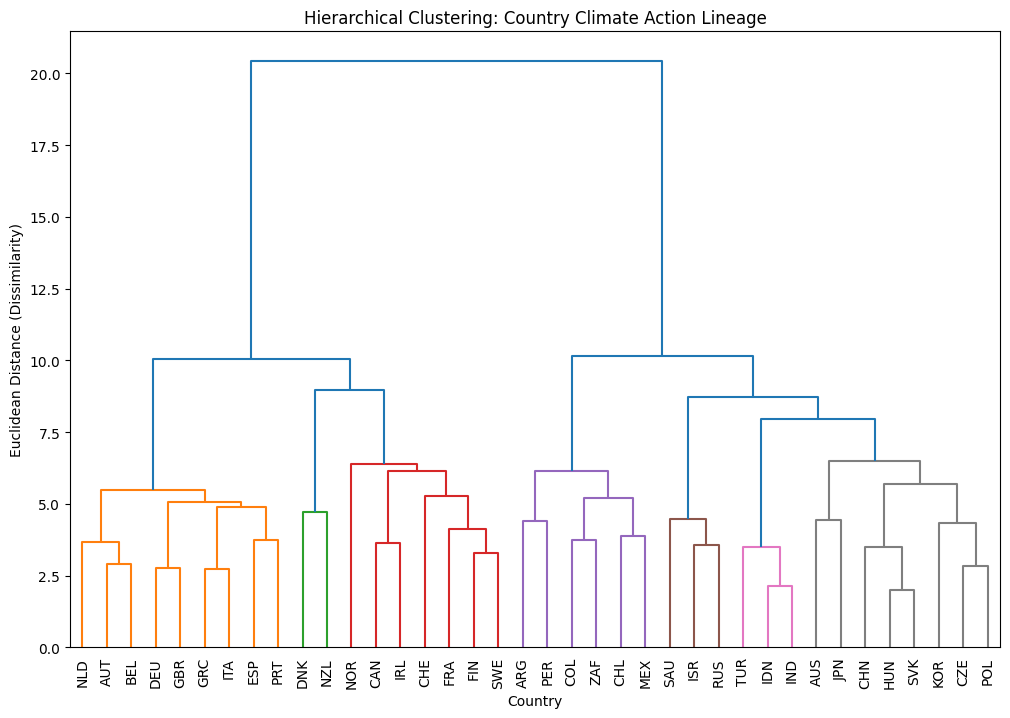

In [32]:
from scipy.cluster.hierarchy import dendrogram, linkage
import matplotlib.pyplot as plt
import pandas as pd

import sys
import os

sys.path.append(os.path.abspath(os.path.join('../..', '..'))) 

from src.preprocessing import preprocess_dataset
from src.preprocessing import preprocess_dataset

# Get the  unscaled data
# Can specify which method to use in the preprocess_dataset function: 'standard' or 'power'
X_scaled = preprocess_dataset('../../../data/processed/cleaned_feature_matrix.csv',
                             '../../../data/processed/cleaned_and_scaled.csv',
                             method='power')

df_averaged = pd.read_csv('../../../data/processed/cleaned_feature_matrix.csv')

X_scaled.index = df_averaged['country_code']

# Generate the linkage matrix 
linked = linkage(X_scaled, method='ward')

# Plot the Dendrogram
plt.figure(figsize=(12, 8))
dendrogram(linked,
           labels=X_scaled.index.values, # Use country codes as labels
           leaf_rotation=90,
           leaf_font_size=10,
           color_threshold=7) # Adjust this to cut at dif levels

plt.title('Hierarchical Clustering: Country Climate Action Lineage')
plt.xlabel('Country')
plt.ylabel('Euclidean Distance (Dissimilarity)')
plt.show()

cutting at about distance 8 seems to be the best option then there are 4 distinct groups...

In [33]:
from scipy.cluster.hierarchy import fcluster

# Cut at 4
k = 4
clusters = fcluster(linked, k, criterion='maxclust')

X_scaled['Hierarchical_Cluster'] = clusters

# Change to int for easier grouping
X_scaled['Hierarchical_Cluster'] = X_scaled['Hierarchical_Cluster'].astype(int)

# Now, look at the averages for each group
cluster_profile = X_scaled.groupby('Hierarchical_Cluster').mean(numeric_only=True)
print(cluster_profile)

                      nd_gain_score  coal_electricity_pct  \
Hierarchical_Cluster                                        
1                              0.29                 -0.08   
2                              1.13                 -0.82   
3                             -1.22                 -0.19   
4                             -0.39                  0.66   

                      renewable_electricity_pct  renewable_final_energy_pct  \
Hierarchical_Cluster                                                          
1                                          0.90                       -0.02   
2                                          0.47                        0.91   
3                                         -0.92                        0.06   
4                                         -0.48                       -0.60   

                      LEV2_CROSS_SEC_CG  LEV3_BAN_PHOUT_COAL  \
Hierarchical_Cluster                                           
1                             

In [34]:

for cluster_num in range(1, k+1):
    countries_in_cluster = X_scaled[X_scaled['Hierarchical_Cluster'] == cluster_num].index.tolist()
    print(f"Cluster {cluster_num}: {countries_in_cluster}")

Cluster 1: ['AUT', 'BEL', 'DEU', 'ESP', 'GBR', 'GRC', 'ITA', 'NLD', 'PRT']
Cluster 2: ['CAN', 'CHE', 'DNK', 'FIN', 'FRA', 'IRL', 'NOR', 'NZL', 'SWE']
Cluster 3: ['ARG', 'CHL', 'COL', 'MEX', 'PER', 'ZAF']
Cluster 4: ['AUS', 'CHN', 'CZE', 'HUN', 'IDN', 'IND', 'ISR', 'JPN', 'KOR', 'POL', 'RUS', 'SAU', 'SVK', 'TUR']


# Super interesting

the smaller economies have the highest carbon tax mean


In [38]:
import plotly.express as px

# Cluster labesl as strings
X_scaled['Cluster_Label'] = X_scaled['Hierarchical_Cluster'].astype(str)

# Create map
fig = px.choropleth(X_scaled, 
                    locations=X_scaled.index,  # Use country codes as locations
                    color="Cluster_Label",    # Colors based archetypes
                    hover_name=df_averaged['Name'],        # Shows the full country name on hover
                    title="Global Climate Action Archetypes (Hierarchical Clustering)",
                    color_discrete_map={      
                        '1': 'orange', 
                        '2': 'red', 
                        '3': 'green', 
                        '4': 'purple'
                    },
                    category_orders={"Cluster_Label": ["1", "2", "3", "4"]})

# Clean up
fig.update_layout(margin={"r":0,"t":50,"l":0,"b":0})
fig.show()

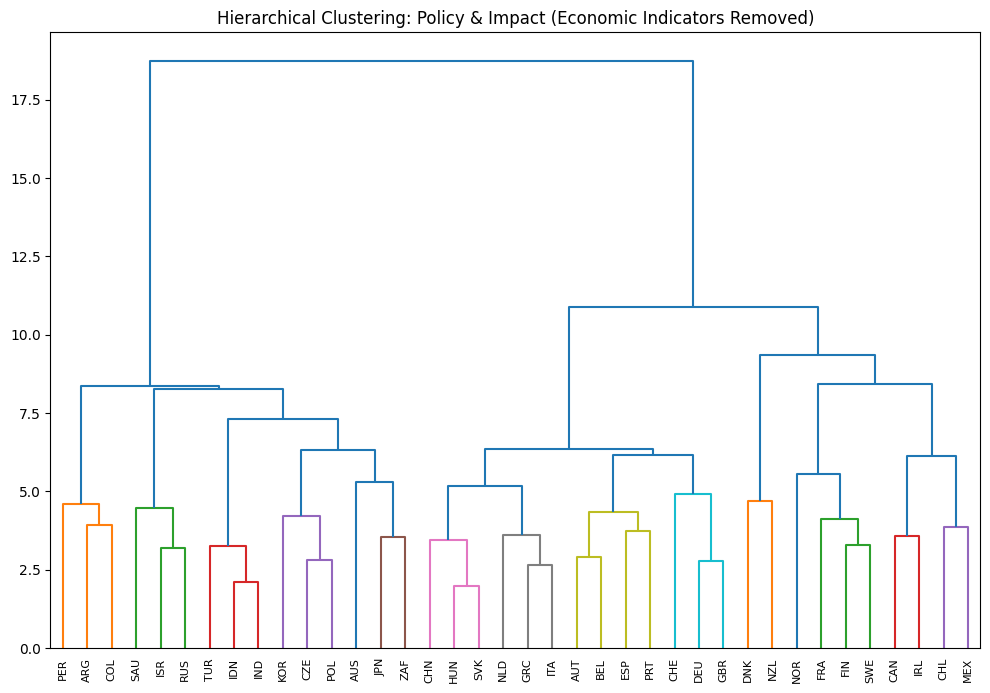

In [ ]:
# Define economic columns to drop
econ_cols = ['gdp_per_capita_constant', 'gdp_constant_usd', 'energy_use_per_capita', 'log_gdp_pc']

# Create the 'Policy-Only' feature set
X_policy_only = X_scaled.drop(columns=[col for col in econ_cols if col in X_scaled.columns])

# Re-run Hierarchical Clustering
from scipy.cluster.hierarchy import linkage, dendrogram

# Generate the linkage matrix for the policy-only features
linked_policy = linkage(X_policy_only, method='ward')

# Plot the new "Policy-Only" Dendrogram
plt.figure(figsize=(12, 8))
dendrogram(linked_policy,
           labels=df_averaged['country_code'].values,
           leaf_rotation=90,
           color_threshold=5) # Adjust threshold for better cluster separation
plt.title('Hierarchical Clustering: Policy & Impact (Economic Indicators Removed)')
plt.show()

In [40]:
import plotly.express as px

# Assign the clusters from the 'Policy-Only' dendrogram

from scipy.cluster.hierarchy import fcluster
policy_clusters = fcluster(linked_policy, 4, criterion='maxclust')
X_policy_only['Policy_Cluster'] = policy_clusters.astype(str)
X_policy_only.index = df_averaged['country_code']  # Ensure the index is set to country codes for mapping

# Create map
fig = px.choropleth(X_policy_only, 
                    locations=X_policy_only.index, 
                    color="Policy_Cluster",
                    hover_name=df_averaged['Name'],
                    title="Climate Action by Policy & Impact (Economic Drivers Removed)",
                    color_discrete_sequence=px.colors.qualitative.Safe) 

fig.update_layout(margin={"r":0,"t":50,"l":0,"b":0})
fig.show()

In [42]:
# Print out the countries in each cluster from the new "Policy-Only" clustering
for cluster_num in range(1, k+1):
    countries_in_cluster = X_policy_only[X_policy_only['Policy_Cluster'] == str(cluster_num)].index.tolist()
    print(f"Policy-Only Cluster {cluster_num}: {countries_in_cluster}")

    

Policy-Only Cluster 1: ['ARG', 'AUS', 'COL', 'CZE', 'IDN', 'IND', 'ISR', 'JPN', 'KOR', 'PER', 'POL', 'RUS', 'SAU', 'TUR', 'ZAF']
Policy-Only Cluster 2: ['AUT', 'BEL', 'CHE', 'CHN', 'DEU', 'ESP', 'GBR', 'GRC', 'HUN', 'ITA', 'NLD', 'PRT', 'SVK']
Policy-Only Cluster 3: ['DNK', 'NZL']
Policy-Only Cluster 4: ['CAN', 'CHL', 'FIN', 'FRA', 'IRL', 'MEX', 'NOR', 'SWE']


In [43]:
from scipy.cluster.hierarchy import fcluster

k = 4

# Cluster assignments for the "Policy-Only" clustering
policy_clusters = fcluster(linked_policy, k, criterion='maxclust')

#  New labels
X_policy_only['Policy_Cluster'] = policy_clusters

# Grouping
policy_cluster_profile = X_policy_only.groupby('Policy_Cluster').mean(numeric_only=True)
# Format the output to be human-readable
pd.options.display.float_format = '{:,.2f}'.format
print("--- Policy-Only Cluster Profiles (Means) ---")
print(policy_cluster_profile.T)

--- Policy-Only Cluster Profiles (Means) ---
Policy_Cluster                 1     2     3     4
nd_gain_score              -0.61  0.15  1.29  0.58
coal_electricity_pct        0.44 -0.10 -0.35 -0.58
renewable_electricity_pct  -0.80  0.54  1.77  0.18
renewable_final_energy_pct -0.50 -0.01  1.01  0.70
LEV2_CROSS_SEC_CG          -0.51 -0.08  1.34  0.76
LEV3_BAN_PHOUT_COAL        -0.84  0.45  0.82  0.63
LEV3_CARBONTAX_I            0.14 -0.52 -0.52  0.70
LEV3_NZ                    -0.74  0.23  0.94  0.78
LEV4_BAN_COAL_STAT         -0.89  0.38  1.03  0.79
LEV4_BAN_EXTRAC_DATE       -0.24 -0.24  4.24 -0.24
LEV4_CARBONTAX_T           -0.18 -0.59  0.40  1.19
LEV4_EE_MANDATE            -0.28  0.66 -0.12 -0.52
LEV4_ETS_E_GHG             -0.90  0.74  0.87  0.27
LEV4_FIT_SOL_PR            -0.03  0.45  0.10 -0.69
LEV4_RENEWABLE_EXP         -0.51  0.10  0.88  0.57
total_policy_score         -1.00  0.41  1.26  0.88
log_energy_pc              -0.28 -0.03  0.26  0.51
policy_score_norm          -0.99  0.4